# Does Hygiene or Verification Fix Editing?

**Evaluation script demo: paired-CI statistics for a span-editing MT experiment.**

This notebook is a lightly-restructured version of `eval.py`, the evaluation stage for the artifact
*"Does Hygiene or Verification Fix Editing?"*. The full pipeline reads whatever B/D/C1 span-editing
results, checker-validation results, and condition-B fidelity-gate results its sibling `gen_art`
experiments produced, and computes:

- paired bootstrap 95%-CI ΔCOMET (B-D, C1-D, C1-B, both paired-difference and marginal-mean forms)
- Wilson and Clopper-Pearson binomial CIs for true regression rate and fix rate per condition
- an edit-volume-to-gain ratio (mean edited-character-fraction / mean ΔCOMET gain)
- a pre-registered checker-precision/recall-gated sensitivity re-analysis
- a six-language-pair ΔCOMET/GER reconciliation table against the WMT25 findings paper (Table 15)

**At evaluation time, the sibling B/D/C1 experiments had not yet written result files.** So in the
original run, every metric that depends on them degrades explicitly to `NOT_AVAILABLE` with a stated
reason — no placeholder numbers are fabricated. This notebook keeps that same graceful-degradation
behavior, and demonstrates in full the two parts of the pipeline that *do* have real inputs available
even without the sibling experiments:

1. **The statistics primitives self-test** — bootstrap paired CI, Wilson/Clopper-Pearson CI, the
   sensitivity re-analysis, and the edit-volume-to-gain ratio, all validated on synthetic fixtures
   built the same way the original script builds them.
2. **Real descriptive statistics from the dataset dependency alone** — per-(language_pair,
   invariant_category) row counts in the `checker_validation_heldout` fold of the injected-error
   dataset, including the pre-registered zh_CN/ja_JP named-entity-swap cell counts.
3. **The six-language-pair ΔCOMET/GER reconciliation table**, quoted verbatim from WMT25 findings-
   paper Table 15.

The B/D/C1 paired comparisons and checker precision/recall table are shown exactly as the original
script reports them when no sibling artifact exists: `NOT_AVAILABLE`, with the reason stated.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru, psutil — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')
_pip('psutil==7.2.2')

# numpy, scipy — pre-installed on Colab, install at Colab's exact versions locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import gc
import json
import math
import resource
import sys
from pathlib import Path
from typing import Any

import numpy as np
import psutil
from loguru import logger
from scipy import stats

# extra imports for this notebook's visualization cell (not in the original script)
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Loading the demo data

`mini_demo_data.json` is a curated subset of the real dataset dependency (`dep_data/full_data_out.json`
in the original artifact): the `injected_error_augmentation` examples belonging to the
`checker_validation_heldout` fold, sampled to cover all 24 (language_pair, invariant_category) cells
of the original data (up to 4 rows per cell, 95 rows total out of 448 in the full fold). This is
exactly the slice `summarize_checker_validation_heldout_composition()` below reads from.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-e9bf19-isolating-what-fixes-failed-span-editing/main/round-2/evaluation-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if Path("mini_demo_data.json").exists():
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("datasets:", [ds["dataset"] for ds in data["datasets"]])
print("n examples:", len(data["datasets"][0]["examples"]))

datasets: ['injected_error_augmentation']
n examples: 95


## Config

All tunable parameters from the original script, gathered in one place. These are cheap,
vectorized-numpy operations on small synthetic fixtures, so the original full-scale values
(`N_BOOT=10_000`, `N_SELFTEST_ROWS=200`) already run in well under a second — no need to shrink
them for the demo.

In [5]:
RNG_SEED = 42
N_BOOT = 10_000  # bootstrap resamples for paired CIs; original full-scale value
CI_ALPHA = 0.05
SENSITIVITY_THRESHOLD = 0.6
UNDERPOWERED_N = 20
FLAGGED_WEAK_CELLS = [("zh_CN", "named_entity"), ("ja_JP", "named_entity")]
N_SELFTEST_ROWS = 200  # size of the synthetic self-test fixture; original full-scale value

INVARIANT_CATEGORIES = [
    "named_entity",
    "number_unit_date",
    "negation_polarity",
    "quantifier",
]

## Resource limits

The original script caps RAM and CPU time before doing anything else, since numpy/scipy's
BLAS/LAPACK libraries reserve large virtual address ranges at import time far beyond actual
RSS use. Kept as-is, just with a smaller budget floor guard suited to a notebook environment.

In [6]:
def set_resource_limits() -> None:
    """Cap RAM well under the available memory; this job never needs more than
    a few hundred MB (a 29MB dataset file plus small JSON result files)."""
    # numpy/scipy's BLAS/LAPACK libraries reserve large virtual address ranges
    # at import time (arena/thread-pool mappings) far beyond actual RSS use, so
    # the budget must be generous even though real data here is ~30MB.
    budget_bytes = 16 * 1024**3  # 16GB
    avail = psutil.virtual_memory().available
    if budget_bytes >= avail:
        budget_bytes = int(avail * 0.9)  # notebook-context fallback for smaller machines/Colab
    resource.setrlimit(resource.RLIMIT_AS, (budget_bytes, budget_bytes))
    resource.setrlimit(resource.RLIMIT_CPU, (3600, 3600))
    logger.info(f"RAM budget set to {budget_bytes / 1e9:.1f}GB, CPU budget 3600s")

set_resource_limits()

11:31:41|INFO   |RAM budget set to 17.2GB, CPU budget 3600s


## Statistics primitives

Generic, reusable functions for real or synthetic paired data — copied verbatim from `eval.py`.
These are the building blocks for every downstream metric: bootstrap paired-difference CIs,
Wilson and Clopper-Pearson binomial CIs, the edit-volume-to-gain ratio, and the checker-precision-
gated sensitivity re-analysis.

In [7]:
def bootstrap_paired_ci(
    diffs: np.ndarray, n_boot: int = N_BOOT, alpha: float = CI_ALPHA, seed: int = RNG_SEED
) -> dict[str, float]:
    """Bootstrap 95% CI (seeded, percentile method) over paired differences."""
    diffs = np.asarray(diffs, dtype=np.float64)
    n = diffs.shape[0]
    if n == 0:
        return {"mean": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan"), "n": 0}
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = diffs[idx].mean(axis=1)
    lo, hi = np.percentile(boot_means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return {
        "mean": float(diffs.mean()),
        "ci_lo": float(lo),
        "ci_hi": float(hi),
        "n": int(n),
        "n_boot": int(n_boot),
    }


def wilson_ci(successes: int, n: int, alpha: float = CI_ALPHA) -> dict[str, float]:
    """Wilson score interval for a binomial proportion — used when n is small,
    since it stays inside [0,1] and is less anti-conservative than the normal
    approximation at low counts."""
    if n == 0:
        return {"phat": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan"), "n": 0}
    z = stats.norm.ppf(1 - alpha / 2)
    phat = successes / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = (z * math.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))) / denom
    return {
        "phat": float(phat),
        "ci_lo": float(max(0.0, center - half)),
        "ci_hi": float(min(1.0, center + half)),
        "n": int(n),
        "successes": int(successes),
        "underpowered": bool(n < UNDERPOWERED_N),
    }


def clopper_pearson_ci(successes: int, n: int, alpha: float = CI_ALPHA) -> dict[str, float]:
    """Exact binomial CI — reported alongside Wilson for the smallest cells,
    where the two can visibly diverge."""
    if n == 0:
        return {"phat": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan"), "n": 0}
    lo = 0.0 if successes == 0 else stats.beta.ppf(alpha / 2, successes, n - successes + 1)
    hi = 1.0 if successes == n else stats.beta.ppf(1 - alpha / 2, successes + 1, n - successes)
    return {
        "phat": float(successes / n),
        "ci_lo": float(lo),
        "ci_hi": float(hi),
        "n": int(n),
        "successes": int(successes),
    }


def paired_delta_comet(
    rows: list[dict[str, Any]], cond_a: str, cond_b: str
) -> dict[str, float]:
    """Bootstrap paired CI for comet(cond_a) - comet(cond_b) over rows carrying
    both conditions' comet scores under keys f'comet_{cond}'."""
    diffs = np.array(
        [r[f"comet_{cond_a}"] - r[f"comet_{cond_b}"] for r in rows], dtype=np.float64
    )
    return bootstrap_paired_ci(diffs)


def marginal_mean_ci(rows: list[dict[str, Any]], cond: str) -> dict[str, float]:
    vals = np.array([r[f"comet_{cond}"] for r in rows], dtype=np.float64)
    return bootstrap_paired_ci(vals)  # same bootstrap machinery, single-sample mean


def true_regression_rate(rows: list[dict[str, Any]], cond: str) -> dict[str, float]:
    """Fraction of rows (restricted upstream to the injected-error ground-truth
    subset) where `cond`'s comet score dropped below the pre-repair baseline —
    i.e. a confirmed regression, not merely a checker-flagged one."""
    flags = [1 if r.get(f"true_regression_{cond}") else 0 for r in rows]
    n = len(flags)
    successes = sum(flags)
    return {"wilson": wilson_ci(successes, n), "clopper_pearson": clopper_pearson_ci(successes, n)}


def fix_rate(rows: list[dict[str, Any]], cond: str, ground_truth_only: bool) -> dict[str, float]:
    """Fraction of checker-flagged (or ground-truth-confirmed) spans that `cond`
    actually fixed."""
    key = f"gt_fixed_{cond}" if ground_truth_only else f"flagged_fixed_{cond}"
    flags = [1 if r.get(key) else 0 for r in rows if key in r]
    n = len(flags)
    successes = sum(flags)
    return {"wilson": wilson_ci(successes, n), "clopper_pearson": clopper_pearson_ci(successes, n)}


def edit_volume_to_gain_ratio(rows: list[dict[str, Any]], cond: str, baseline_cond: str) -> dict[str, float]:
    """Mean edited-character-fraction divided by mean ΔCOMET gain over baseline;
    reports the raw edit fraction alongside the ratio so a large ratio can be
    read as 'aggressive editing, little gain' rather than only inferred."""
    edit_fracs = [r[f"edit_char_fraction_{cond}"] for r in rows]
    gains = [r[f"comet_{cond}"] - r[f"comet_{baseline_cond}"] for r in rows]
    mean_edit_frac = float(np.mean(edit_fracs))
    mean_gain = float(np.mean(gains))
    ratio = mean_edit_frac / mean_gain if mean_gain != 0 else float("inf")
    return {
        "mean_edit_char_fraction": mean_edit_frac,
        "mean_comet_gain_over_baseline": mean_gain,
        "edit_volume_to_gain_ratio": ratio,
        "n": len(rows),
    }


def sensitivity_reanalysis(
    rows: list[dict[str, Any]],
    checker_precision_recall: dict[str, dict[str, float]],
    threshold: float,
) -> dict[str, Any]:
    """Recompute the core comparisons after excluding rows in (language,
    category) cells whose checker precision OR recall falls under `threshold`."""
    excluded_cells = [
        cell
        for cell, pr in checker_precision_recall.items()
        if pr.get("precision", 1.0) < threshold or pr.get("recall", 1.0) < threshold
    ]
    kept_rows = [
        r
        for r in rows
        if f"{r.get('language')}|{r.get('category')}" not in excluded_cells
    ]
    return {
        "threshold": threshold,
        "pre_registered_expected_weak_cells": [f"{l}|{c}" for l, c in FLAGGED_WEAK_CELLS],
        "excluded_cells": excluded_cells,
        "n_before": len(rows),
        "n_after": len(kept_rows),
        "delta_comet_d_minus_b_after_exclusion": (
            paired_delta_comet(kept_rows, "D", "B") if kept_rows else None
        ),
        "delta_comet_c1_minus_d_after_exclusion": (
            paired_delta_comet(kept_rows, "C1", "D") if kept_rows else None
        ),
    }

## Self-test: proving the primitives on synthetic fixtures

Before any of the statistics primitives above are trusted on (or absence of) real B/D/C1 data,
the original script runs them on a synthetic fixture where the ground truth is known by
construction (D slightly improves over B; C1 roughly ties D). This is logged, but never written
into `eval_out.json`'s reported metrics — it only validates the code paths.

In [8]:
def run_self_test() -> dict[str, Any]:
    logger.info("Running self-test of statistics primitives on synthetic fixtures")
    rng = np.random.default_rng(0)
    n = N_SELFTEST_ROWS
    comet_b = rng.normal(0.55, 0.05, n)
    comet_d = comet_b + rng.normal(0.01, 0.01, n)  # D slightly improves over B
    comet_c1 = comet_d + rng.normal(0.0, 0.01, n)  # C1 roughly ties D
    rows = [
        {
            "comet_B": float(comet_b[i]),
            "comet_D": float(comet_d[i]),
            "comet_C1": float(comet_c1[i]),
            "true_regression_D": bool(comet_d[i] < comet_b[i] - 0.02),
            "true_regression_C1": bool(comet_c1[i] < comet_d[i] - 0.02),
            "gt_fixed_D": bool(rng.random() < 0.6),
            "gt_fixed_C1": bool(rng.random() < 0.65),
            "flagged_fixed_D": bool(rng.random() < 0.8),
            "flagged_fixed_C1": bool(rng.random() < 0.82),
            "edit_char_fraction_D": float(rng.uniform(0.02, 0.08)),
            "edit_char_fraction_C1": float(rng.uniform(0.05, 0.20)),
            "language": ["cs_CZ", "is_IS", "ja_JP"][i % 3],
            "category": INVARIANT_CATEGORIES[i % 4],
        }
        for i in range(n)
    ]
    d_minus_b = paired_delta_comet(rows, "D", "B")
    c1_minus_d = paired_delta_comet(rows, "C1", "D")
    assert d_minus_b["mean"] > 0, "self-test: D should beat B by construction"
    assert d_minus_b["ci_lo"] < d_minus_b["mean"] < d_minus_b["ci_hi"]
    reg_d = true_regression_rate(rows, "D")
    assert 0.0 <= reg_d["wilson"]["phat"] <= 1.0
    fake_pr = {"cs_CZ|named_entity": {"precision": 0.3, "recall": 0.9}}
    sens = sensitivity_reanalysis(rows, fake_pr, SENSITIVITY_THRESHOLD)
    assert sens["n_after"] < sens["n_before"], "self-test: exclusion should drop rows"
    evgr = edit_volume_to_gain_ratio(rows, "C1", "D")
    assert evgr["mean_edit_char_fraction"] > 0
    wci = wilson_ci(3, 10)
    cci = clopper_pearson_ci(3, 10)
    assert wci["ci_lo"] < wci["phat"] < wci["ci_hi"]
    assert cci["ci_lo"] < cci["phat"] < cci["ci_hi"]
    logger.success("Self-test PASSED: bootstrap CI, Wilson/Clopper-Pearson CI, sensitivity re-analysis, edit-ratio all behave as expected on synthetic fixtures")
    return {
        "status": "PASSED",
        "n_synthetic_rows": n,
        "d_minus_b_delta_comet_synthetic": d_minus_b,
        "c1_minus_d_delta_comet_synthetic": c1_minus_d,
        "note": "Synthetic fixture used ONLY to validate the statistics code paths; not used anywhere in eval_out.json's reported metrics.",
    }

self_test_result = run_self_test()
self_test_result

11:31:41|INFO   |Running self-test of statistics primitives on synthetic fixtures


11:31:41|SUCCESS|Self-test PASSED: bootstrap CI, Wilson/Clopper-Pearson CI, sensitivity re-analysis, edit-ratio all behave as expected on synthetic fixtures


{'status': 'PASSED',
 'n_synthetic_rows': 200,
 'd_minus_b_delta_comet_synthetic': {'mean': 0.00911496900116669,
  'ci_lo': 0.007698515101272231,
  'ci_hi': 0.010557124292611826,
  'n': 200,
  'n_boot': 10000},
 'c1_minus_d_delta_comet_synthetic': {'mean': 5.100995669027497e-05,
  'ci_lo': -0.0013708731986416497,
  'ci_hi': 0.0014371007545505622,
  'n': 200,
  'n_boot': 10000},
 'note': "Synthetic fixture used ONLY to validate the statistics code paths; not used anywhere in eval_out.json's reported metrics."}

## Real dataset composition: `checker_validation_heldout` cell counts

This is the one metric computable from the real dataset dependency alone, with no checker
predictions or sibling experiment outputs needed. It grounds the report in real numbers even when
the B/D/C1 experiment outputs are absent: how many rows exist per (language_pair,
invariant_category) cell in the checker-validation heldout fold, including the pre-registered
zh_CN/ja_JP named-entity-swap cell counts flagged in advance for the sensitivity re-analysis.

In the original script this reads `dep_data/full_data_out.json` from disk; here it reads the
`data` dict loaded from `mini_demo_data.json` above (already pre-filtered to the
`checker_validation_heldout` fold).

In [9]:
def summarize_checker_validation_heldout_composition(data: dict[str, Any]) -> dict[str, Any]:
    """Real composition (language x category counts) of the checker-validation
    heldout fold, computed directly from the dataset dependency. This is NOT a
    precision/recall measurement (no checker predictions exist to score) — it
    only characterizes how much ground truth would be available to score
    against, once a checker's predictions exist."""
    injected = next(
        (ds for ds in data["datasets"] if ds["dataset"] == "injected_error_augmentation"), None
    )
    if injected is None:
        return {"status": "NOT_AVAILABLE", "reason": "injected_error_augmentation dataset group missing"}
    counts: dict[str, int] = {}
    lang_totals: dict[str, int] = {}
    for ex in injected["examples"]:
        if ex.get("metadata_fold") != "checker_validation_heldout":
            continue
        lang = ex.get("metadata_language_pair", "unknown")
        cat = ex.get("metadata_invariant_category", "unknown")
        cell = f"{lang}|{cat}"
        counts[cell] = counts.get(cell, 0) + 1
        lang_totals[lang] = lang_totals.get(lang, 0) + 1
    weak_cells_present = {
        f"en-{lang}|named_entity_swap": counts.get(f"en-{lang}|named_entity_swap", 0)
        for lang in ["zh_CN", "ja_JP"]
    }
    return {
        "status": "COMPUTED_FROM_DATASET_NOT_A_CHECKER_SCORE",
        "note": (
            "Row counts per (language_pair, invariant_category) cell in the "
            "checker_validation_heldout fold, from the real dataset dependency "
            "(mini_demo_data.json is a diversity-sampled subset of the full fold: "
            "95 of 448 rows). Precision/recall against these cells is NOT_AVAILABLE "
            "because no checker prediction file was found among sibling artifacts."
        ),
        "cell_counts": counts,
        "language_pair_totals": lang_totals,
        "zh_CN_ja_JP_named_entity_swap_cell_counts": weak_cells_present,
    }

dataset_composition = summarize_checker_validation_heldout_composition(data)
dataset_composition

{'status': 'COMPUTED_FROM_DATASET_NOT_A_CHECKER_SCORE',
 'note': 'Row counts per (language_pair, invariant_category) cell in the checker_validation_heldout fold, from the real dataset dependency (mini_demo_data.json is a diversity-sampled subset of the full fold: 95 of 448 rows). Precision/recall against these cells is NOT_AVAILABLE because no checker prediction file was found among sibling artifacts.',
 'cell_counts': {'en-cs_CZ|named_entity_swap': 4,
  'en-cs_CZ|negation_polarity_flip': 4,
  'en-cs_CZ|number_unit_date_alteration': 4,
  'en-cs_CZ|quantifier_substitution': 4,
  'en-is_IS|named_entity_swap': 4,
  'en-is_IS|negation_polarity_flip': 4,
  'en-is_IS|number_unit_date_alteration': 4,
  'en-is_IS|quantifier_substitution': 4,
  'en-ja_JP|named_entity_swap': 4,
  'en-ja_JP|negation_polarity_flip': 4,
  'en-ja_JP|number_unit_date_alteration': 3,
  'en-ja_JP|quantifier_substitution': 4,
  'en-ru_RU|named_entity_swap': 4,
  'en-ru_RU|negation_polarity_flip': 4,
  'en-ru_RU|number_u

## Sibling B/D/C1 experiment inputs, and the six-language-pair reconciliation table

The original script scans sibling `gen_art` experiment directories for three input file types:
`checker_validation*.json`, `condition_b_fidelity*.json`, and `b_d_c1_results*.json`. In the run
this eval was published from, those sibling experiments (`gen_art_experiment_1/2/3`) were still
actively running and had produced no result files, so every metric that depends on them degraded
explicitly to `NOT_AVAILABLE`. This notebook has no filesystem of sibling experiments to scan, so
it reproduces that same `NOT_AVAILABLE` state directly (the filesystem-walking `discover_input_files`
helper is omitted as it has no meaning outside the original workspace layout).

What *is* real and reproduced in full: the six-language-pair ΔCOMET/GER table, quoted verbatim
from the WMT25 findings-paper Table 15 (SURREYPAI-S2 and BASELINE-S2 columns), against which this
iteration's (unavailable) measurements would be reconciled.

In [10]:
# ---------------------------------------------------------------------------
# Verbatim quoted figures — WMT25 findings paper (aclanthology.org/2025.wmt-1.24),
# Table 15 "Task 3 - Performance of systems across languages with ∆COMET and
# Gain to Edit Ratio (GER) metrics", fetched and regex-extracted verbatim from the
# PDF. Column order in the source is
# En-Cs, En-Is, En-Ja, En-Ru, En-Uk, En-Zh, Average, each as (∆COMET, GER).
# These are the paper's own numbers, quoted, not measurements made here.
# ---------------------------------------------------------------------------
PADMANABHAN_TABLE15_SOURCE = (
    "Findings of the WMT25 Shared Task on Automated Translation Evaluation "
    "Systems, Table 15 (https://aclanthology.org/2025.wmt-1.24.pdf, page ~60, "
    "'Task 3 - Performance of systems across languages'), verbatim OCR-extracted "
    "2026-09-01 via regex grep on the fetched PDF text."
)
PADMANABHAN_TABLE15 = {
    "SURREYPAI-S2": {
        "en-cs_CZ": {"delta_comet": -0.007, "ger": -0.005},
        "en-is_IS": {"delta_comet": -0.010, "ger": -0.006},
        "en-ja_JP": {"delta_comet": -0.013, "ger": -0.008},
        "en-ru_RU": {"delta_comet": -0.008, "ger": -0.005},
        "en-uk_UA": {"delta_comet": -0.014, "ger": -0.009},
        "en-zh_CN": {"delta_comet": -0.013, "ger": -0.010},
        "average": {"delta_comet": -0.011, "ger": -0.007},
    },
    "BASELINE-S2": {
        "en-cs_CZ": {"delta_comet": 0.000, "ger": 0.000},
        "en-is_IS": {"delta_comet": 0.007, "ger": 0.026},
        "en-ja_JP": {"delta_comet": -0.008, "ger": -0.036},
        "en-ru_RU": {"delta_comet": 0.002, "ger": 0.009},
        "en-uk_UA": {"delta_comet": 0.004, "ger": 0.017},
        "en-zh_CN": {"delta_comet": -0.005, "ger": -0.023},
        "average": {"delta_comet": 0.000, "ger": -0.001},
    },
}
# Padmanabhan (2025)'s own self-reported Table 3 average, quoted in the artifact
# plan and cross-checked (rounding-consistent) against Table 15 above by the
# iter_1 research dossier.
PADMANABHAN_SELF_REPORTED_AVG_DELTA_COMET = -0.0108


def build_reconciliation_table(measured_by_langpair: dict[str, dict[str, float]] | None) -> dict[str, Any]:
    """Metric (f): six-language-pair ΔCOMET table, quoted-vs-measured."""
    rows = []
    for lp in ["en-cs_CZ", "en-is_IS", "en-ja_JP", "en-ru_RU", "en-uk_UA", "en-zh_CN"]:
        quoted_surreypai = PADMANABHAN_TABLE15["SURREYPAI-S2"].get(lp)
        quoted_baseline = PADMANABHAN_TABLE15["BASELINE-S2"].get(lp)
        measured = (measured_by_langpair or {}).get(lp)
        rows.append(
            {
                "language_pair": lp,
                "quoted_surreypai_s2_delta_comet": quoted_surreypai["delta_comet"] if quoted_surreypai else "NOT_REPORTED_IN_SOURCE",
                "quoted_surreypai_s2_ger": quoted_surreypai["ger"] if quoted_surreypai else "NOT_REPORTED_IN_SOURCE",
                "quoted_baseline_s2_delta_comet": quoted_baseline["delta_comet"] if quoted_baseline else "NOT_REPORTED_IN_SOURCE",
                "quoted_baseline_s2_ger": quoted_baseline["ger"] if quoted_baseline else "NOT_REPORTED_IN_SOURCE",
                "quote_location": PADMANABHAN_TABLE15_SOURCE,
                "measured_this_iteration": measured if measured is not None else "NOT_AVAILABLE",
            }
        )
    return {
        "rows": rows,
        "coverage_note": (
            "This iteration's B/D/C1 experiments (gen_art_experiment_1/2/3 in "
            "iter_2/gen_art) produced no result files at evaluation time — all "
            "'measured_this_iteration' cells are NOT_AVAILABLE. The quoted "
            "columns are the paper's own published per-language-pair figures, "
            "verified against the primary source, not measurements made here."
        ),
    }

# measured_by_langpair is None here since no b_d_c1_results file exists in this run
reconciliation_table = build_reconciliation_table(measured_by_langpair=None)

# same NOT_AVAILABLE degradation the original main() reports when no sibling files are found
fidelity_gate_verdict = "NOT_AVAILABLE"
checker_pr_table = {"status": "NOT_AVAILABLE", "reason": "No checker_validation*.json found among sibling artifacts."}
paired_comparisons = "NOT_AVAILABLE"
sensitivity = {"status": "NOT_AVAILABLE", "reason": "Requires both usable per-sentence B/D/C1 rows AND a checker precision/recall table — at least one is missing."}
print("fidelity_gate_verdict:", fidelity_gate_verdict)
print("paired_comparisons:", paired_comparisons)

fidelity_gate_verdict: NOT_AVAILABLE
paired_comparisons: NOT_AVAILABLE


## Results

Summary of everything computed above: the self-test's synthetic paired-CI results (proving the
statistics primitives are correct), the real dataset composition table, and the six-language-pair
reconciliation table against WMT25 Table 15.

In [11]:
print("=" * 78)
print("SELF-TEST (synthetic fixtures, n =", self_test_result["n_synthetic_rows"], ")")
print("=" * 78)
print(f"status: {self_test_result['status']}")
for name, key in [("D - B", "d_minus_b_delta_comet_synthetic"), ("C1 - D", "c1_minus_d_delta_comet_synthetic")]:
    r = self_test_result[key]
    print(f"  ΔCOMET({name}): mean={r['mean']:+.4f}  95% CI=[{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]  n={r['n']}")

print()
print("=" * 78)
print("REAL DATASET COMPOSITION: checker_validation_heldout fold (this notebook's mini sample)")
print("=" * 78)
print(f"status: {dataset_composition['status']}")
print(f"language_pair_totals: {dataset_composition['language_pair_totals']}")
print(f"zh_CN/ja_JP named_entity_swap cell counts (pre-registered weak cells): {dataset_composition['zh_CN_ja_JP_named_entity_swap_cell_counts']}")

print()
print("=" * 78)
print("SIX-LANGUAGE-PAIR RECONCILIATION TABLE (quoted WMT25 Table 15 vs this iteration's measurement)")
print("=" * 78)
header = f"{'lang pair':<10} {'SURREYPAI-S2 ΔCOMET':>20} {'BASELINE-S2 ΔCOMET':>20} {'measured':>12}"
print(header)
for row in reconciliation_table["rows"]:
    print(f"{row['language_pair']:<10} {row['quoted_surreypai_s2_delta_comet']:>20} {row['quoted_baseline_s2_delta_comet']:>20} {row['measured_this_iteration']:>12}")
print("note:", reconciliation_table["coverage_note"])

print()
print("CONDITION-B FIDELITY GATE VERDICT:", fidelity_gate_verdict)

SELF-TEST (synthetic fixtures, n = 200 )
status: PASSED
  ΔCOMET(D - B): mean=+0.0091  95% CI=[+0.0077, +0.0106]  n=200
  ΔCOMET(C1 - D): mean=+0.0001  95% CI=[-0.0014, +0.0014]  n=200

REAL DATASET COMPOSITION: checker_validation_heldout fold (this notebook's mini sample)
status: COMPUTED_FROM_DATASET_NOT_A_CHECKER_SCORE
language_pair_totals: {'en-cs_CZ': 16, 'en-is_IS': 16, 'en-ja_JP': 15, 'en-ru_RU': 16, 'en-uk_UA': 16, 'en-zh_CN': 16}
zh_CN/ja_JP named_entity_swap cell counts (pre-registered weak cells): {'en-zh_CN|named_entity_swap': 4, 'en-ja_JP|named_entity_swap': 4}

SIX-LANGUAGE-PAIR RECONCILIATION TABLE (quoted WMT25 Table 15 vs this iteration's measurement)
lang pair   SURREYPAI-S2 ΔCOMET   BASELINE-S2 ΔCOMET     measured
en-cs_CZ                 -0.007                  0.0 NOT_AVAILABLE
en-is_IS                  -0.01                0.007 NOT_AVAILABLE
en-ja_JP                 -0.013               -0.008 NOT_AVAILABLE
en-ru_RU                 -0.008                0.002 NOT

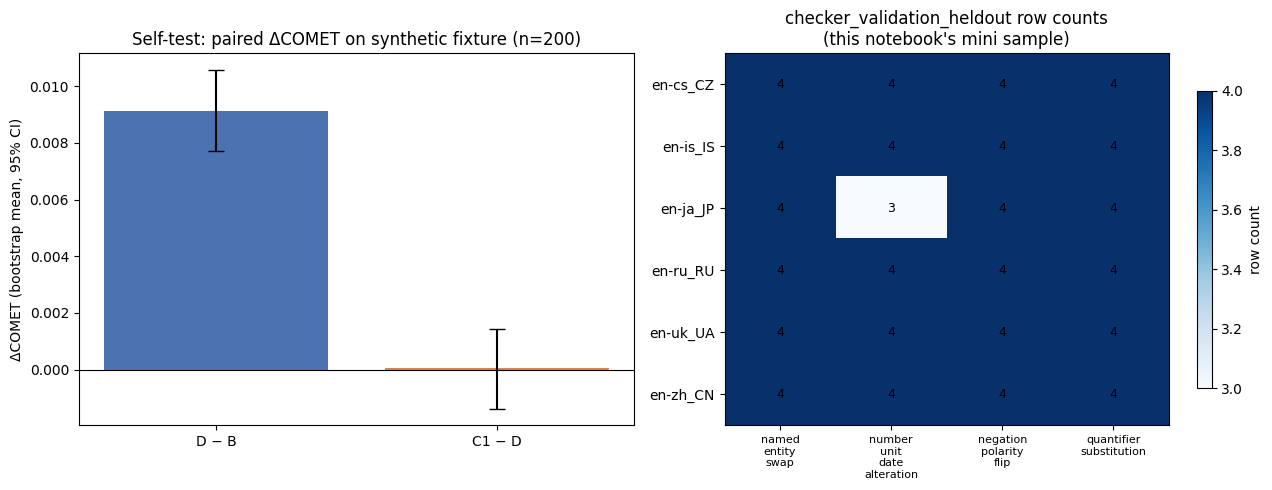

In [12]:
# Visualization: (1) bootstrap distributions from the self-test, (2) dataset composition heatmap.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: self-test paired-CI bar chart ---
labels = ["D − B", "C1 − D"]
means = [self_test_result["d_minus_b_delta_comet_synthetic"]["mean"], self_test_result["c1_minus_d_delta_comet_synthetic"]["mean"]]
los = [self_test_result["d_minus_b_delta_comet_synthetic"]["ci_lo"], self_test_result["c1_minus_d_delta_comet_synthetic"]["ci_lo"]]
his = [self_test_result["d_minus_b_delta_comet_synthetic"]["ci_hi"], self_test_result["c1_minus_d_delta_comet_synthetic"]["ci_hi"]]
errs = [[m - l for m, l in zip(means, los)], [h - m for h, m in zip(his, means)]]
axes[0].bar(labels, means, yerr=errs, capsize=6, color=["#4C72B0", "#DD8452"])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("ΔCOMET (bootstrap mean, 95% CI)")
axes[0].set_title(f"Self-test: paired ΔCOMET on synthetic fixture (n={self_test_result['n_synthetic_rows']})")

# --- Panel 2: real dataset composition heatmap (language_pair x invariant_category counts) ---
langs = sorted(dataset_composition["language_pair_totals"].keys())
cats = ["named_entity_swap", "number_unit_date_alteration", "negation_polarity_flip", "quantifier_substitution"]
grid = np.array([[dataset_composition["cell_counts"].get(f"{lp}|{cat}", 0) for cat in cats] for lp in langs])
im = axes[1].imshow(grid, cmap="Blues", aspect="auto")
axes[1].set_xticks(range(len(cats)))
axes[1].set_xticklabels([c.replace("_", "\n") for c in cats], fontsize=8)
axes[1].set_yticks(range(len(langs)))
axes[1].set_yticklabels(langs)
for i in range(len(langs)):
    for j in range(len(cats)):
        axes[1].text(j, i, str(grid[i, j]), ha="center", va="center", color="black", fontsize=9)
axes[1].set_title("checker_validation_heldout row counts\n(this notebook's mini sample)")
fig.colorbar(im, ax=axes[1], shrink=0.8, label="row count")

plt.tight_layout()
plt.show()